## Desafio 1 — Borrar Fundo com Detecção de Face

A ideia é bem direta: detectar onde a face está e borrar tudo ao redor, como o efeito de fundo do Google Meet. O Haar Cascade é um detector clássico — funciona bem para face frontal, mas é bem mais limitado que os detectores modernos baseados em redes neurais.

### Instalação e Importação da Biblioteca

In [1]:
!pip install opencv-python matplotlib

In [2]:
import cv2
import matplotlib.pyplot as plt

### Ler Imagens

OpenCV lê em BGR por padrão, então precisa converter antes de mostrar com matplotlib.

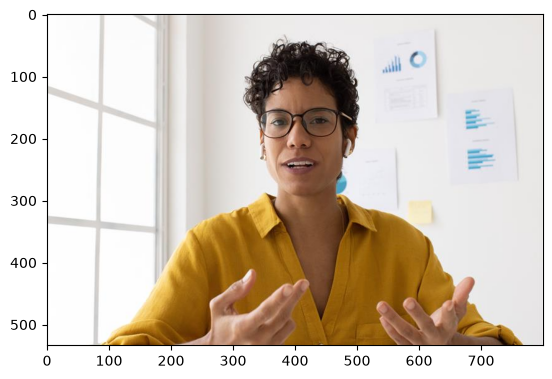

In [3]:
image_bgr = cv2.imread("desafio_1.jpeg")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

### Transformar em Escala de Cinza

O Haar Cascade opera em escala de cinza — sem essa conversão ele não detecta nada.

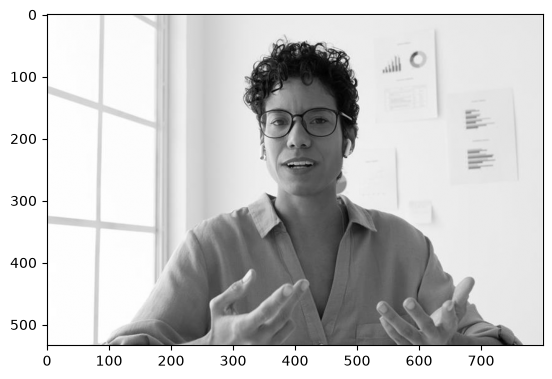

In [4]:
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
plt.imshow(image_gray, cmap="gray")

### Detectar as Faces

Para isso iremos utilizar o `haar cascade` um método de detecção de faces clásscio. Mais detalhes sobre o `haar cascade` [aqui](https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html)

O padding de 100px inclui um pouco de pescoço e cabelo — sem ele a borda ficava muito abrupta na transição entre a face nítida e o fundo borrado.

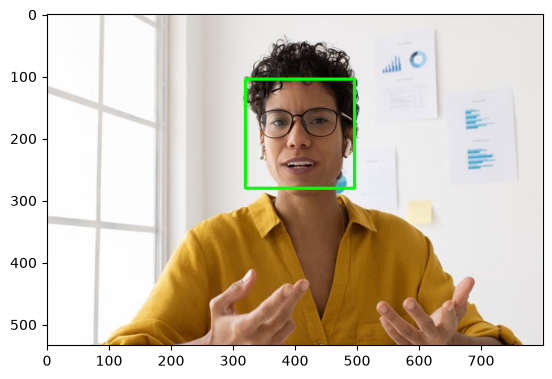

In [5]:
detec = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
face = detec.detectMultiScale(image_gray, 1.3, 3)
copy_image_rgb = image_rgb.copy()

padding = 100

for (x, y, larg, alt) in face: #Desenhar o retângulo
    ret = cv2.rectangle(copy_image_rgb, (x, y), (x + larg, y + alt), (0, 255, 0), 3)
    y, height = max(0, y-padding), min(y+alt+padding, image_rgb.shape[0])
    x, width = max(0, x-padding), min(x+larg+padding, image_rgb.shape[1])
    face_img = image_rgb[y:height,x:width,:]
plt.imshow(copy_image_rgb)

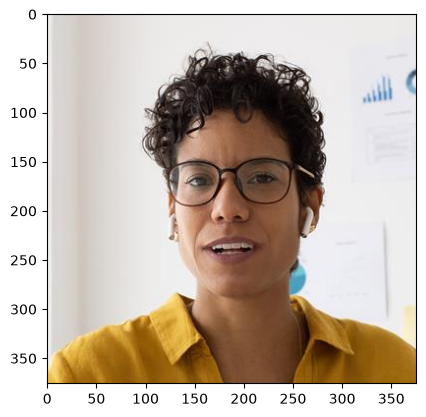

In [6]:
plt.imshow(face_img)

### Borrar a Imagem inteira

Kernel `(15, 15)` com sigma `20` deu um borrado bem visível. Testei com `(5, 5)` mas ficava fraco demais — a pessoa ainda aparecia claramente no fundo.

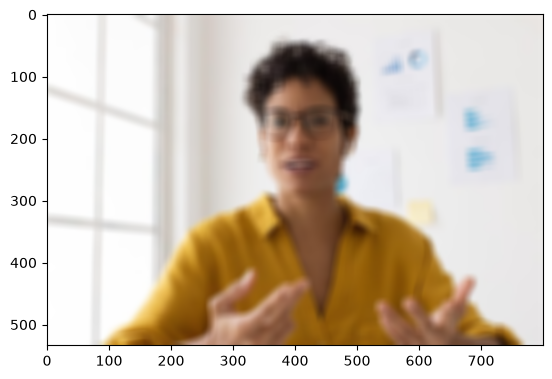

In [7]:
blured_image = cv2.GaussianBlur(image_rgb, (15, 15), 20)
plt.imshow(blured_image)

### Substituir Imagem Original da Face na Imagem Borrada

Copia a imagem borrada e substitui a região da face com os pixels originais.

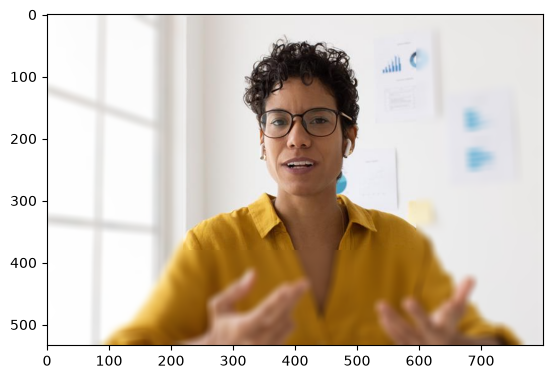

In [8]:
final_image = blured_image.copy()
final_image[y:height, x:width, :] = face_img
plt.imshow(final_image)